# Simulation of Multi-mode Interferometer

## Step 0: Open the Lumerical MODE session

In [6]:
%load_ext autoreload
%autoreload 2
# Remember to remove the lines after
import lumapi
from collections import OrderedDict
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functools import partial
from IPython.display import display
import logging


# Find the repository root from the current notebook working directory.
base_path = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "data" / "stack").is_dir()
)

import sys
sys.path.append(str(base_path))
import lumapi_util as lu


# Open the session and build the first geometry (edit the build_geometry.lsf script)
sim = lumapi.MODE()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Step 1: Create the geometry

Define the geometry function and set the default parameters.
> Edit this script to customize the geometry


In [ ]:
import lumapi_util

sim.switchtolayout()
sim.deleteall()

# Define the parameters

default_params = {
    "w_wg": 1,
    "w_mmi": 5,
    "ln_mmi": 10,
    "ln_taper": 0.5,
    "input_length": 2,
    "input_cell_length": 1.5,
    "n_points": 22,
    "sidewall_angle": 90,
    "layers": ["SIN"],
    "wavelength": 1.55,
    "n_modes": 15,
    "n_cells": 1,
    "bc": ["PML", "PML", "Symmetric", "PML"]
    }

stack_length = 55
stack_file = base_path / "data" / "stack" / "ullsin_layer_stack.lbr"
lu.add_layerstack_fromfile(sim, filename=stack_file.as_posix(), size=[stack_length, 50, None])


def set_port_mode(sim, port_number, mode_number=1, neff=None):
    sim.select(f"EME::Ports::port_{port_number}")
    sim.set("mode selection", "user select")
    if neff is None:
        sim.seteigensolver("use max index", 1)
    else:
        sim.seteigensolver("use max index", 0)
        sim.seteigensolver("n", neff)
    sim.set("selected mode numbers", mode_number)
    sim.updateportmodes()


def set_ports_mode(sim, ports_spec):
    sim.switchtolayout()
    for spec in ports_spec:
        set_port_mode(
            sim,
            spec["port"],
            spec.get("mode", 1),
            spec.get("neff", None),
        )


# Build the three-section 2x2 geometry.
def mod_geometry(sim, **params):
    params = {**default_params, **params}
    wavelength = params["wavelength"]

    sim.switchtolayout()
    sim.setnamed("layer group", "geometry", {})

    left_ext = 2
    taper_ln = params["ln_taper"]
    input_length = params["input_length"]
    input_cell_length = params["input_cell_length"]
    mmi_ln = params["ln_mmi"]
    mmi_width = params["w_mmi"]
    wg_spacing = params.get("s_wg", mmi_width / 2)
    wg_width = params["w_wg"]
    ap_width = params.get("w_ap", wg_width)

    taper = lu.build_profile_taper(
        wg_width,
        ap_width,
        length=taper_ln,
        extension=(left_ext, 0),
    )
    mmi_wg = lu.straight_waveguide(mmi_ln, mmi_width)
    input_wg = lu.straight_waveguide(input_length, wg_width)

    geometries = [
        input_wg + np.array([-taper_ln, wg_spacing / 2]),
        taper + np.array([0, wg_spacing / 2]),
        taper + np.array([0, -wg_spacing / 2]),
        mmi_wg + np.array([left_ext + taper_ln, 0]),
        lu.rotate(taper, 180) + np.array([
            2 * left_ext + 2 * taper_ln + mmi_ln,
            wg_spacing / 2,
        ]),
        lu.rotate(taper, 180) + np.array([
            2 * left_ext + 2 * taper_ln + mmi_ln,
            -wg_spacing / 2,
        ]),
    ]

    layers = params["layers"]
    if params.get("t") is not None:
        sim.select("layer group")
        sim.setlayer(layers[0], "thickness", params["t"] * 1e-6)

    for layer in layers:
        sim.select("layer group")
        sim.setlayer(layer, "sidewall angle", params["sidewall_angle"])
        lu.set_geometries_to_layer(sim, geometries=geometries, layer=layer)

    wg_info = lu.get_layer_info(sim, layers[0])
    zc = wg_info["z0"] + wg_info["t"] / 2
    n_cells = params.get("n_cells", 20)
    if n_cells > 1:
        eme_cells = [
            (1, 1.),
            (n_cells, taper_ln),
            (1, mmi_ln),
            (n_cells, taper_ln),
            (1, 1.),
        ]
    else:
        eme_cells = [(1, input_cell_length), (1, mmi_ln), (1, 0.5)]

    sim_width = params.get("sim_width", mmi_width + 5)
    lu.define_eme(
        sim,
        wavelength=wavelength,
        size=[None, sim_width, 3.],
        center=[1., 0., zc],
        cells=eme_cells,
        bc=params.get("bc", ["Metal"] * 4),
        n_modes=params.get("n_modes", 10),
    )

    lu.define_mesh(
        sim,
        name="mesh_struct",
        size=[stack_length, params["w_mmi"], 0.2],
        center=[stack_length / 2, 0., zc],
        steps=[None, wavelength / 20, wavelength / 20],
    )
    lu.define_eme_profile(sim, size=[60, 20, None], center=[30., 0., zc])
    lu.define_eme_profile(sim, size=[None, 10, 10], center=[12.75, 0., zc])

    lu.define_eme_port(sim, port_number=1, offset=-1.5e-6)
    lu.define_eme_port(sim, port_number=3, location="right")
    set_ports_mode(sim, [
        {"port": 2, "mode": 1},
        {"port": 3, "mode": 2},
    ])


mod_geometry(sim, sidewall_angle=90)


[ensure_object] 'EME' not found. Creating a new 'EME'...
[ensure_object] 'mesh_struct' not found. Creating a new 'mesh'...
[ensure_object] 'profile z-normal' not found. Creating a new 'emeprofile'...
[ensure_object] 'profile x-normal' not found. Creating a new 'emeprofile'...
[ensure_object] 'EME::Ports::port_3' not found. Creating a new 'emeport'...


## Input-section coupling check

The modeled input is a single upper waveguide, but the lower parallel branch is already present in the first EME section. The `input_length` parameter changes the physical fed lead; `input_cell_length` changes the first EME cell, which is the relevant length for checking whether both branches coexist before the MMI region.

The following diagnostic is geometric only. A small edge gap and a nonzero parallel length indicate that coupling may occur, but only an eigenmode or propagation solve can determine the coupling coefficient and transferred power.


In [25]:
def input_section_coupling_check(
    input_cell_length=1.5,
    left_extension=2.0,
    taper_length=0.5,
    wg_spacing=2.25,
    wg_width=2.0,
    aperture_width=None,
):
    """Report whether the unexcited input branch is nearby in the first cell."""
    aperture_width = wg_width if aperture_width is None else aperture_width
    parallel_length = min(input_cell_length, left_extension + taper_length)
    minimum_edge_gap = wg_spacing - max(wg_width, aperture_width)
    return pd.Series({
        "first_cell_length_um": input_cell_length,
        "parallel_branch_length_um": parallel_length,
        "minimum_edge_gap_um": minimum_edge_gap,
        "second_branch_present": parallel_length > 0,
        "coupling_possible": parallel_length > 0 and minimum_edge_gap > 0,
        "geometry_warning": (
            "The unexcited branch is present beside the fed branch. "
            "Quantify coupling with an eigenmode or propagation solve."
            if parallel_length > 0 and minimum_edge_gap > 0
            else "No parallel branch is present in the checked section."
        ),
    })


input_coupling_check = input_section_coupling_check(
    input_cell_length=1.5,
    wg_spacing=2.25,
    wg_width=2.0,
)
display(input_coupling_check.to_frame("value"))


,value
first_cell_length_um,1.5
parallel_branch_length_um,1.5
minimum_edge_gap_um,0.25
second_branch_present,True
coupling_possible,True
geometry_warning,The unexcited branch is present beside the fed...


## General theory of multi-mode interferometer


Reference: **"Optical Multi-Mode Interference Devices Based on Self-Imaging: Principles and Applications"** by Soldano and Pennings (1995) 

---

### **Key Concepts**

1. **Self-Imaging Principle**:

   * In multimode waveguides, an input field can reproduce itself (or its mirrored/multiple images) at specific intervals along the propagation direction due to **constructive interference** between supported modes.

2. **Three Main Interference Mechanisms**:

   * **General Interference**: No restrictions on mode excitation.
   * **Paired Interference**: Only specific modes (e.g., v = 2, 5, 8...) are excited.
   * **Symmetric Interference**: Only even symmetric modes are excited.

---

### **Important Equations**

#### 1. **Waveguide Mode Propagation Constants**

Given a step-index multimode waveguide:

$$
k_0^2 n_r^2 = k_{y,v}^2 + \beta_v^2 \tag{1}
$$

$$
k_{y,v} = \frac{(v+1)\pi}{W_{\text{eff}}} \tag{2}
$$

$$
\beta_v \approx k_0 n_r \left[1 - \frac{1}{2} \left( \frac{(v+1)\lambda_0}{2n_r W_{\text{eff}}} \right)^2 \right] \tag{3}
$$

Where:

* $\beta_v$: Propagation constant of the v-th mode.
* $W_{\text{eff}}$: Effective width of the multimode region.
* $n_r$: Effective index of the waveguide core.
* $k_0 = \frac{2\pi}{\lambda_0}$: Free-space wavenumber.

---

#### 2. **Beat Length Between Fundamental Modes**

$$
L_\pi = \frac{\pi}{\beta_0 - \beta_1} \approx \frac{4n_r W_{\text{eff}}^2}{3\lambda_0} \tag{4}
$$

This length defines the periodicity of self-imaging.
One could express the beat length using the *effective indices* that are found by simulation

$$
L_\pi = \frac{\lambda_0 / 2}{n_{eff,0} - n_{eff,1}} 
$$

---

#### 3. **Field Expansion and Propagation**

Input field decomposition:

$$
\phi(y, 0) = \sum_{v=0}^{m-1} c_v \psi_v(y) \tag{5}
$$

Field after propagation distance $z$:

$$
\phi(y, z) = \sum_{v=0}^{m-1} c_v \psi_v(y) e^{-j\beta_v z} \tag{6}
$$

---

#### 4. **Imaging Conditions**

Self-imaging occurs when phase differences satisfy:

* **Direct Image**: $\beta_0 - \beta_v = \frac{2\pi p_v}{L}$
* **Mirrored Image**: Even/odd modes in anti-phase.

#### Beat Length for **General Interference** (for any N)

$$
L = p(3L_\pi),\quad p \in \mathbb{Z} \tag{7}
$$

For N-fold images (general case):

$$
L = \frac{p}{N}(3L_\pi),\quad \text{gcd}(p,N)=1 \tag{8}
$$



#### Beat Length for **Symmetric Interference** (for 1xN, especially 1x2)

In symmetric interference, **only even symmetric modes** are excited: $v = 0, 2, 4, \dots$.

Because of this restriction, the **periodicity of phase accumulation reduces by a factor of 4**. Therefore:


$$
L = \frac{p}{N}\left(\frac{3L_\pi}{4}\right),\quad p \in \mathbb{Z} \tag{8}
$$

In particular, for the first order $p=1$ and for 1x2 splitter we have:
$$
L = \frac{3}{8}L_\pi \tag{9}
$$

The input location must be at
$$
y = 0
$$

whereas the output must be at
$$
y = \pm \frac{W_{\text{eff}}}{4} 
$$


####  Beat Length for **Paired Interference** (for 2xN, especially 2x2)

In paired interference, **only modes with $v = 0, 1, 3, 4, 6, 7, \dots$** are excited (i.e., excluding $v = 2, 5, 8, \dots$).

This results in a **tripled periodicity** due to repeating structure in $v(v + 2) \mod 3$. Hence:

$$
L = p\left(L_\pi\right),\quad p \in \mathbb{Z} \tag{7}
$$

For N-fold images (general case):

$$
L = \frac{p}{N}\left(L_\pi\right),\quad p \in \mathbb{Z} \tag{8}
$$

The input and the output locations must be at
$$
y = \pm \frac{W_{\text{eff}}}{6} 
$$


---

#### 5. **Phase Relation in N×N MMI Couplers**

The relative output phase for inputs T and outputs s:

* For $T + s$ even:

$$
\phi_{rs} = \frac{\pi}{4N}(s-1)(2N + T - s) + \pi \tag{11}
$$

* For $T + s$ odd:

$$
\phi_{rs} = -\frac{\pi}{4N}(r + s - 1)(2N - T - s + 1) \tag{12}
$$

---






## 2x2 port reduction and supermode decomposition

This design uses three modeled sections: one aligned input waveguide, the multimode interference region, and two output waveguides. We excite only the aligned input. At the output, the first two resolved modes are treated as the even and odd supermodes of the two output waveguides.

For physical upper/lower output amplitudes $a_u$ and $a_l$, the normalized basis conversion is

$$
\begin{bmatrix} a_u \\ a_l \end{bmatrix}
= \frac{1}{\sqrt{2}}
\begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix}
\begin{bmatrix} a_{\mathrm{even}} \\ a_{\mathrm{odd}} \end{bmatrix}.
$$

The reconstructed port order is `[left upper, left lower, right upper, right lower]`. Mirror symmetry and reciprocity reconstruct the unmodeled excitation columns from the measured forward and input-reflection amplitudes. The reconstruction is therefore a symmetry model, not a claim that four independent excitations were simulated.

Input-side reflected modes must be supplied separately when return loss is evaluated. Missing reflection data is not replaced with residual-power estimates.


In [8]:
# Estimate paired-interference imaging lengths from analytical or simulated L_pi models.
def effective_width_model(W_um, lambda_0_um, n_core, n_clad):
    delta = (lambda_0_um / (2 * np.pi)) / np.sqrt(n_core**2 - n_clad**2)
    return W_um + 2 * delta


def lpi_from_effective_width_model(n_r, n_core, n_clad, W_um):
    def model(lambda_0_um):
        W_eff = effective_width_model(W_um, lambda_0_um, n_core, n_clad)
        return (4 * n_r * W_eff**2) / (3 * lambda_0_um)
    return model


def lpi_from_simulation(n0, n1):
    def model(lambda_0_um):
        return lambda_0_um / (2 * (n0 - n1))
    return model


def compute_mmi_lengths(lambda_0_um, L_pi_model):
    L_pi = L_pi_model(lambda_0_um)
    lengths = {
        "L_pi": L_pi,
        "2x2 3dB (general)": 1.5 * L_pi,
        "2x2 cross (general)": 3 * L_pi,
        "2x2 3dB (paired)": 0.5 * L_pi,
        "2x2 cross (paired)": L_pi,
    }
    return pd.DataFrame({
        "Parameter": list(lengths.keys()),
        "Length (um)": [round(value, 3) for value in lengths.values()],
    })


## Function for sweeps

In [9]:
import numpy as np


# 2x2 modal decomposition and figures of merit

# Port ordering for the reconstructed 4x4 matrix:
# [left upper, left lower, right upper, right lower].
# The simulated input is left upper. The first two output modes are
# interpreted as even and odd supermodes of the two right waveguides.
SUPER_MODE_TO_OUTPUT = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)


def _power_db(power):
    return 10 * np.log10(abs(power))


def supermodes_to_outputs(even_amplitude, odd_amplitude):
    """Convert even/odd output supermode amplitudes to physical outputs."""
    supermode_amplitudes = np.asarray([even_amplitude, odd_amplitude], dtype=complex)
    return SUPER_MODE_TO_OUTPUT @ supermode_amplitudes


def outputs_to_supermodes(upper_amplitude, lower_amplitude):
    """Convert physical output amplitudes to even/odd supermode amplitudes."""
    return SUPER_MODE_TO_OUTPUT.conj().T @ np.asarray(
        [upper_amplitude, lower_amplitude], dtype=complex
    )


def reconstruct_smatrix(forward_outputs, reflected_inputs):
    """Reconstruct a symmetric reciprocal 4x4 S matrix from one excitation.

    `forward_outputs` and `reflected_inputs` are physical amplitudes ordered as
    [upper, lower]. The reconstruction assumes mirror symmetry and reciprocity;
    no unmeasured term is silently treated as a measured result.
    """
    forward_outputs = np.asarray(forward_outputs, dtype=complex)
    reflected_inputs = np.asarray(reflected_inputs, dtype=complex)
    if forward_outputs.shape != (2,) or reflected_inputs.shape != (2,):
        raise ValueError("Both amplitude vectors must have shape (2,).")

    upper, lower = forward_outputs
    reflection, cross_reflection = reflected_inputs
    return np.array([
        [reflection, cross_reflection, upper, lower],
        [cross_reflection, reflection, lower, upper],
        [upper, lower, reflection, cross_reflection],
        [lower, upper, cross_reflection, reflection],
    ], dtype=complex)


def wrap_phase_error(phase_difference):
    """Return the absolute phase error from the nearest +/-90 degree relation."""
    phase_difference = np.angle(np.exp(1j * phase_difference))
    errors = [
        abs(np.angle(np.exp(1j * (phase_difference - target))))
        for target in (np.pi / 2, -np.pi / 2)
    ]
    return np.rad2deg(min(errors))


def compute_2x2_metrics(forward_outputs, reflected_inputs):
    """Return 2x2 coupler metrics and the reconstructed scattering matrix."""
    forward_outputs = np.asarray(forward_outputs, dtype=complex)
    reflected_inputs = np.asarray(reflected_inputs, dtype=complex)
    if forward_outputs.shape != (2,) or reflected_inputs.shape != (2,):
        raise ValueError("Both amplitude vectors must have shape (2,).")

    output_power = np.abs(forward_outputs) ** 2
    reflected_power = np.abs(reflected_inputs) ** 2
    total_forward_power = float(np.sum(output_power))
    total_reflected_power = float(np.sum(reflected_power))
    if total_forward_power <= 0:
        raise ValueError("Forward output power must be positive.")

    phase_difference = np.angle(forward_outputs[1] / forward_outputs[0])
    output_imbalance_db = float(_power_db(output_power[0] / output_power[1]))
    return {
        "excess_loss_db": float(-_power_db(total_forward_power)),
        "insertion_loss_upper_db": float(-_power_db(output_power[0])),
        "insertion_loss_lower_db": float(-_power_db(output_power[1])),
        "power_imbalance_db": output_imbalance_db,
        "phase_error_deg": float(wrap_phase_error(phase_difference)),
        "return_loss_db": float(-_power_db(total_reflected_power)) if total_reflected_power > 0 else np.inf,
        "forward_power": total_forward_power,
        "reflected_power": total_reflected_power,
        "forward_outputs": forward_outputs,
        "reflected_inputs": reflected_inputs,
        "reconstructed_smatrix": reconstruct_smatrix(forward_outputs, reflected_inputs),
    }


def validate_2x2_decomposition():
    """Check basis conversion and the ideal balanced 2x2 metric convention."""
    ideal_outputs = supermodes_to_outputs(1 / np.sqrt(2), 1j / np.sqrt(2))
    metrics = compute_2x2_metrics(ideal_outputs, np.zeros(2, dtype=complex))
    assert np.allclose(outputs_to_supermodes(*ideal_outputs), [1 / np.sqrt(2), 1j / np.sqrt(2)])
    assert np.isclose(metrics["power_imbalance_db"], 0)
    assert np.isclose(metrics["phase_error_deg"], 0)
    assert np.isinf(metrics["return_loss_db"])
    return metrics


validate_2x2_decomposition()


{'excess_loss_db': 9.643274665532871e-16,
 'insertion_loss_upper_db': 3.010299956639813,
 'insertion_loss_lower_db': 3.010299956639813,
 'power_imbalance_db': 0.0,
 'phase_error_deg': 0.0,
 'return_loss_db': inf,
 'forward_power': 0.9999999999999998,
 'reflected_power': 0.0,
 'forward_outputs': array([0.5+0.5j, 0.5-0.5j]),
 'reflected_inputs': array([0.+0.j, 0.+0.j]),
 'reconstructed_smatrix': array([[0. +0.j , 0. +0.j , 0.5+0.5j, 0.5-0.5j],
        [0. +0.j , 0. +0.j , 0.5-0.5j, 0.5+0.5j],
        [0.5+0.5j, 0.5-0.5j, 0. +0.j , 0. +0.j ],
        [0.5-0.5j, 0.5+0.5j, 0. +0.j , 0. +0.j ]])}

## MMI2x2 - C band TE

In [17]:
device_name = "mmi2x2_cte"

mmi_params = {
    "wavelength": 1.55,
    "w_wg": 2,
    "w_mmi": 7.5,
    "s_wg": 2.25,
}

mod_geometry(sim, **mmi_params)
lu.run_eme(sim, f"{device_name}.lms")


In [19]:
def amplitudes_from_smatrix(
    S,
    output_mode_rows=(1, 2),
    input_column=0,
):
    """Extract the two output supermodes and measured input reflection.

    The reduced model has one aligned input and two output supermodes, so the
    user S matrix is 3x3. The missing cross-reflection amplitude is set to zero
    because the second physical input is intentionally not modeled.
    """
    S = np.asarray(S, dtype=complex)
    if S.ndim != 2 or S.shape[0] < 3 or S.shape[1] <= input_column:
        raise ValueError("Expected a 3x3-or-larger user S matrix.")

    output_modes = S[list(output_mode_rows), input_column]
    reflected_inputs = np.array([
        S[input_column, input_column],
        0j,
    ], dtype=complex)
    return output_modes, reflected_inputs


def compute_coupler_metrics_from_sim(
    sim,
    output_mode_rows=(1, 2),
    input_column=0,
):
    """Run EME propagation and calculate metrics plus raw supermode data."""
    S = lu.run_eme_propagation(sim)
    supermode_amplitudes, reflected_inputs = amplitudes_from_smatrix(
        S,
        output_mode_rows=output_mode_rows,
        input_column=input_column,
    )
    forward_outputs = supermodes_to_outputs(*supermode_amplitudes)
    metrics = compute_2x2_metrics(forward_outputs, reflected_inputs)
    metrics.update({
        "even_amplitude_abs": float(abs(supermode_amplitudes[0])),
        "odd_amplitude_abs": float(abs(supermode_amplitudes[1])),
        "even_power": float(abs(supermode_amplitudes[0]) ** 2),
        "odd_power": float(abs(supermode_amplitudes[1]) ** 2),
        "even_phase_deg": float(np.rad2deg(np.angle(supermode_amplitudes[0]))),
        "odd_phase_deg": float(np.rad2deg(np.angle(supermode_amplitudes[1]))),
        "supermode_phase_difference_deg": float(
            np.rad2deg(np.angle(supermode_amplitudes[1] / supermode_amplitudes[0]))
        ),
        "supermode_amplitudes": supermode_amplitudes,
    })
    return metrics


def metric_record(metrics):
    """Keep sweep tables numeric while retaining the raw diagnostic objects."""
    return {
        key: value
        for key, value in metrics.items()
        if np.isscalar(value) and not isinstance(value, complex)
    }


def _resolve_notebook_result_path(filename):
    path = Path(filename)
    if not path.is_absolute() and path.parent == Path("."):
        path = base_path / "results" / path
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def mmi_length_sweep(sim, lengths, filename, lpi_um=None, **result_kwargs):
    records = []
    for length in lengths:
        lu.set_eme_group_lengths(sim, 1, length)
        record = {
            "length_um": length,
            **metric_record(compute_coupler_metrics_from_sim(sim, **result_kwargs)),
        }
        if lpi_um is not None:
            record["length_over_lpi"] = length / lpi_um
        records.append(record)
    summary = pd.DataFrame(records)
    summary.to_csv(_resolve_notebook_result_path(filename), index=False)
    return summary


def lpi_length_sweep(
    sim,
    lpi_um,
    multiples=np.linspace(0.25, 2.5, 91),
    filename="mmi2x2_lpi_length_sweep.csv",
    **result_kwargs,
):
    """Sweep several beat lengths and return modal and coupler metrics."""
    lengths = np.asarray(multiples, dtype=float) * lpi_um
    return mmi_length_sweep(
        sim,
        lengths=lengths,
        filename=filename,
        lpi_um=lpi_um,
        **result_kwargs,
    )


def select_best_2x2_length(summary, metric="excess_loss_db"):
    """Select the lowest-loss balanced point from a modal length sweep."""
    valid = summary.dropna(subset=[metric, "power_imbalance_db", "phase_error_deg"])
    valid = valid[valid["power_imbalance_db"].abs() <= 1.0]
    valid = valid[valid["phase_error_deg"] <= 10.0]
    if valid.empty:
        valid = summary.dropna(subset=[metric])
    return valid.loc[valid[metric].idxmin()]


def set_wavelength_analysis(sim, wavelength):
    sim.setemeanalysis("override wavelength", True)
    sim.setemeanalysis("wavelength", wavelength * 1e-6)


def wavelength_sweep(sim, wavelengths, filename, **result_kwargs):
    records = []
    for wavelength in wavelengths:
        set_wavelength_analysis(sim, wavelength)
        records.append({
            "wavelength_um": wavelength,
            **metric_record(compute_coupler_metrics_from_sim(sim, **result_kwargs)),
        })
    sim.setemeanalysis("override wavelength", False)
    summary = pd.DataFrame(records)
    summary.to_csv(_resolve_notebook_result_path(filename), index=False)
    return summary


def plot_2x2_metrics(summary, x_column):
    metric_columns = [
        "excess_loss_db",
        "power_imbalance_db",
        "phase_error_deg",
        "insertion_loss_upper_db",
        "insertion_loss_lower_db",
        "return_loss_db",
    ]
    axes = summary.plot(
        x=x_column,
        y=metric_columns,
        subplots=True,
        layout=(3, 2),
        figsize=(12, 10),
        legend=False,
    )
    return axes


def plot_supermode_evolution(summary, x_column="length_over_lpi"):
    """Plot output supermode magnitudes and unwrapped phases."""
    x_values = summary[x_column]
    even_phase = np.rad2deg(np.unwrap(np.deg2rad(summary["even_phase_deg"])))
    odd_phase = np.rad2deg(np.unwrap(np.deg2rad(summary["odd_phase_deg"])))
    phase_difference = np.rad2deg(np.unwrap(np.deg2rad(odd_phase - even_phase)))

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(x_values, summary["even_amplitude_abs"], label="even")
    axes[0].plot(x_values, summary["odd_amplitude_abs"], label="odd")
    axes[0].set_ylabel("Amplitude")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(x_values, even_phase, label="even")
    axes[1].plot(x_values, odd_phase, label="odd")
    axes[1].plot(x_values, phase_difference, label="odd-even")
    axes[1].set_xlabel("MMI length / L_pi")
    axes[1].set_ylabel("Unwrapped phase (deg)")
    axes[1].legend()
    axes[1].grid(True)
    fig.tight_layout()
    return fig, axes


In [23]:
def plot_2x2_metrics(summary, x_column):
    metric_specs = [
        ("excess_loss_db", "Excess loss", "Loss (dB)"),
        ("power_imbalance_db", "Output power imbalance", "Imbalance (dB)"),
        ("phase_error_deg", "Relative phase error", "Phase error (deg)"),
        ("insertion_loss_upper_db", "Upper-output insertion loss", "Insertion loss (dB)"),
        ("insertion_loss_lower_db", "Lower-output insertion loss", "Insertion loss (dB)"),
        ("return_loss_db", "Input return loss", "Return loss (dB)"),
    ]
    x_label = "MMI length / L_pi" if x_column == "length_over_lpi" else x_column
    fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
    axes = axes.ravel()

    for axis, (column, title, y_label) in zip(axes, metric_specs):
        axis.plot(summary[x_column], summary[column], linewidth=1.8)
        axis.set_title(title)
        axis.set_ylabel(y_label)
        axis.grid(True, which="both", alpha=0.35)
        axis.axhline(0, color="black", linewidth=0.7, alpha=0.5)

    for axis in axes[-2:]:
        axis.set_xlabel(x_label)
    fig.suptitle("2x2 MMI figures of merit", fontsize=14)
    fig.tight_layout()
    return fig, axes


def plot_supermode_evolution(summary, x_column="length_over_lpi"):
    """Plot output supermode magnitudes and correctly unwrapped phases."""
    x_values = summary[x_column]
    even_phase = np.rad2deg(np.unwrap(np.deg2rad(summary["even_phase_deg"])))
    odd_phase = np.rad2deg(np.unwrap(np.deg2rad(summary["odd_phase_deg"])))
    relative_phase = np.rad2deg(
        np.unwrap(np.deg2rad(summary["supermode_phase_difference_deg"]))
    )

    fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
    axes[0].plot(x_values, summary["even_amplitude_abs"], label="Even supermode", linewidth=1.8)
    axes[0].plot(x_values, summary["odd_amplitude_abs"], label="Odd supermode", linewidth=1.8)
    axes[0].set_title("Output supermode amplitudes")
    axes[0].set_ylabel("Amplitude (normalized)")
    axes[0].grid(True, which="both", alpha=0.35)
    axes[0].legend()

    axes[1].plot(x_values, even_phase, label="Even phase", linewidth=1.8)
    axes[1].plot(x_values, odd_phase, label="Odd phase", linewidth=1.8)
    axes[1].plot(x_values, relative_phase, label="Odd - even relative phase", linewidth=1.8)
    axes[1].set_title("Output supermode phases")
    axes[1].set_xlabel("MMI length / L_pi")
    axes[1].set_ylabel("Unwrapped phase (deg)")
    axes[1].grid(True, which="both", alpha=0.35)
    axes[1].axhline(0, color="black", linewidth=0.7, alpha=0.5)
    axes[1].legend()

    fig.suptitle("Supermode evolution through the MMI", fontsize=14)
    fig.tight_layout()
    return fig, axes


## Propagation-only longitudinal sweeps

Once `lu.run_eme(...)` has solved the transverse modes, changing an EME group span is a longitudinal change. These sweeps update the group span and call `lu.run_eme_propagation(...)` only. Rebuild the geometry and rerun EME only when a transverse property changes, such as width, spacing, layer, mesh, or port mode definition.


In [26]:
def propagation_only_length_sweep(
    sim,
    lengths,
    cell_range,
    filename,
    lpi_um=None,
    **result_kwargs,
):
    """Sweep an EME span after modes are solved; never rerun the EME solver."""
    if sim.layoutmode():
        raise RuntimeError(
            "The EME modes are not solved. Run lu.run_eme once before this sweep."
        )

    records = []
    for length in np.asarray(lengths, dtype=float):
        lu.set_eme_group_lengths(sim, cell_range, length)
        record = {
            "length_um": length,
            "cell_range": cell_range,
            **metric_record(compute_coupler_metrics_from_sim(sim, **result_kwargs)),
        }
        if lpi_um is not None:
            record["length_over_lpi"] = length / lpi_um
        records.append(record)

    summary = pd.DataFrame(records)
    summary.to_csv(_resolve_notebook_result_path(filename), index=False)
    return summary


def input_section_length_sweep(
    sim,
    lengths,
    filename="mmi2x2_input_section_length_sweep.csv",
    **result_kwargs,
):
    """Sweep the first EME section, which is group 0 in this notebook."""
    return propagation_only_length_sweep(
        sim,
        lengths=lengths,
        cell_range=0,
        filename=filename,
        **result_kwargs,
    )


In [14]:
S_live = lu.run_eme_propagation(sim)
print("user S matrix shape:", np.asarray(S_live).shape)
print(S_live)

metrics_live = compute_coupler_metrics_from_sim(sim)
print(metric_record(metrics_live))


user S matrix shape: (3, 3)
[[ 6.12445903e-03-2.72295964e-02j -4.20748066e-01+3.82475523e-01j
  -6.92074014e-02-4.99332783e-01j]
 [-4.20683105e-01+3.82444302e-01j -2.45757074e-02-5.41912972e-03j
  -3.86191133e-15+1.11359047e-14j]
 [-6.91455555e-02-4.99331455e-01j -4.60358057e-15+1.19364148e-14j
  -2.19889279e-02-2.38026334e-02j]]
{'excess_loss_db': 2.385601313940271, 'insertion_loss_upper_db': 8.968897830186016, 'insertion_loss_lower_db': 3.462535677942051, 'power_imbalance_db': -5.506362152243966, 'phase_error_deg': 8.314270206904338, 'return_loss_db': 31.084848875318873, 'forward_power': 0.5773509285260114, 'reflected_power': 0.0007789599201297895}


Best constrained 2x2 length:
length_um                         132.500000
excess_loss_db                      0.127231
insertion_loss_upper_db             2.763936
insertion_loss_lower_db             3.546314
power_imbalance_db                  0.782378
phase_error_deg                     0.987724
return_loss_db                     51.846076
forward_power                       0.971129
reflected_power                     0.000007
even_amplitude_abs                  0.702781
odd_amplitude_abs                   0.690817
even_power                          0.493901
odd_power                           0.477228
even_phase_deg                    138.547739
odd_phase_deg                      53.702433
supermode_phase_difference_deg    -84.845305
length_over_lpi                     1.325000
Name: 33, dtype: float64


(<Figure size 1100x800 with 2 Axes>,
 array([<Axes: title={'center': 'Output supermode amplitudes'}, ylabel='Amplitude (normalized)'>,
        <Axes: title={'center': 'Output supermode phases'}, xlabel='MMI length / L_pi', ylabel='Unwrapped phase (deg)'>],
       dtype=object))

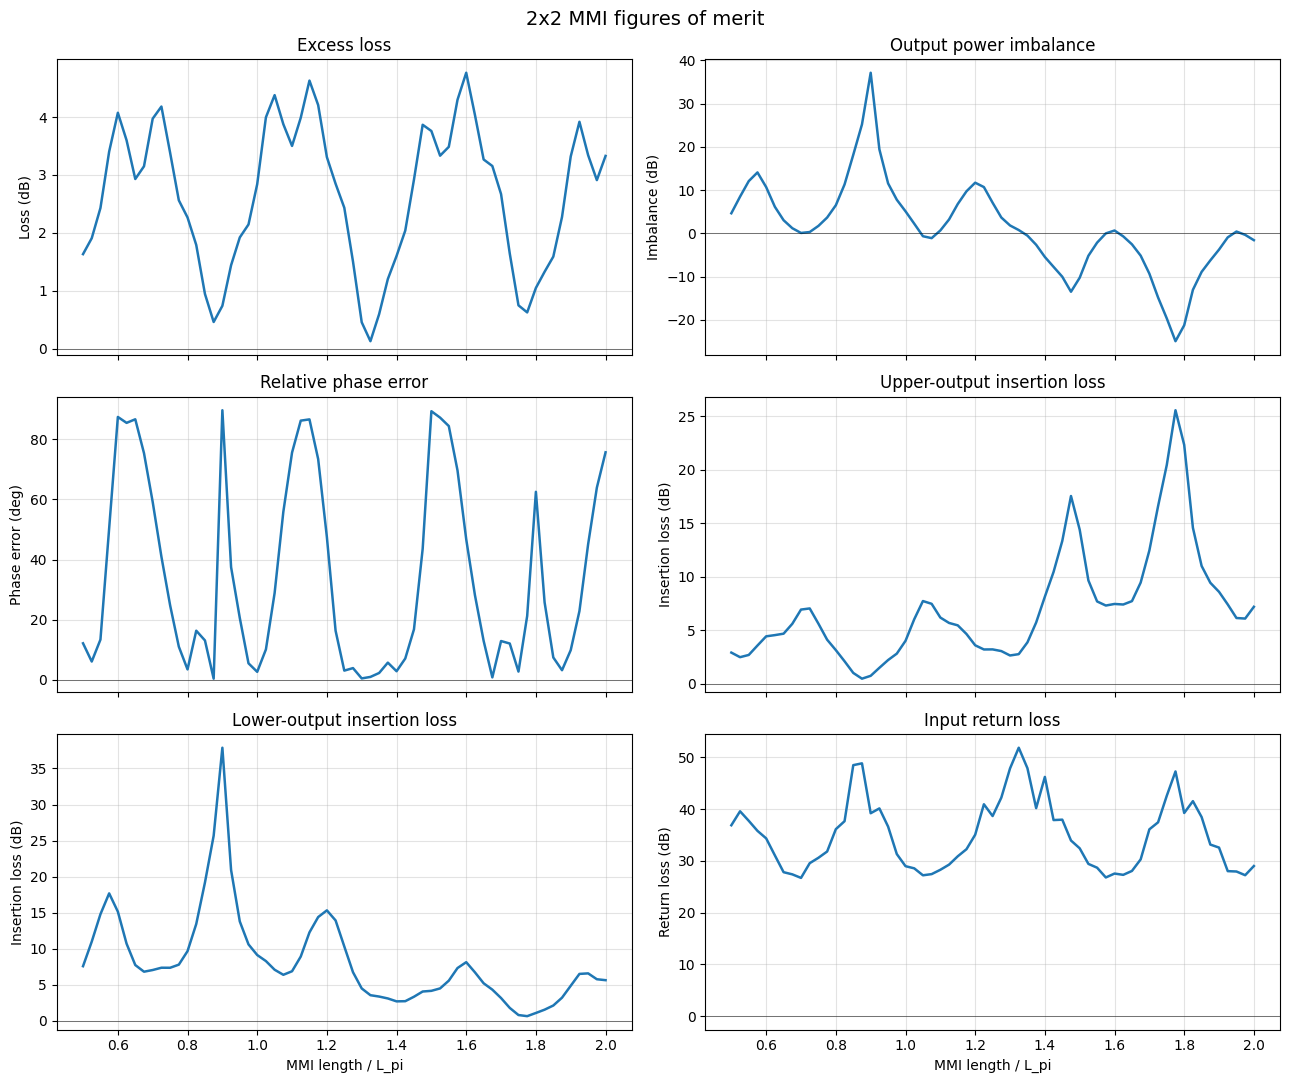

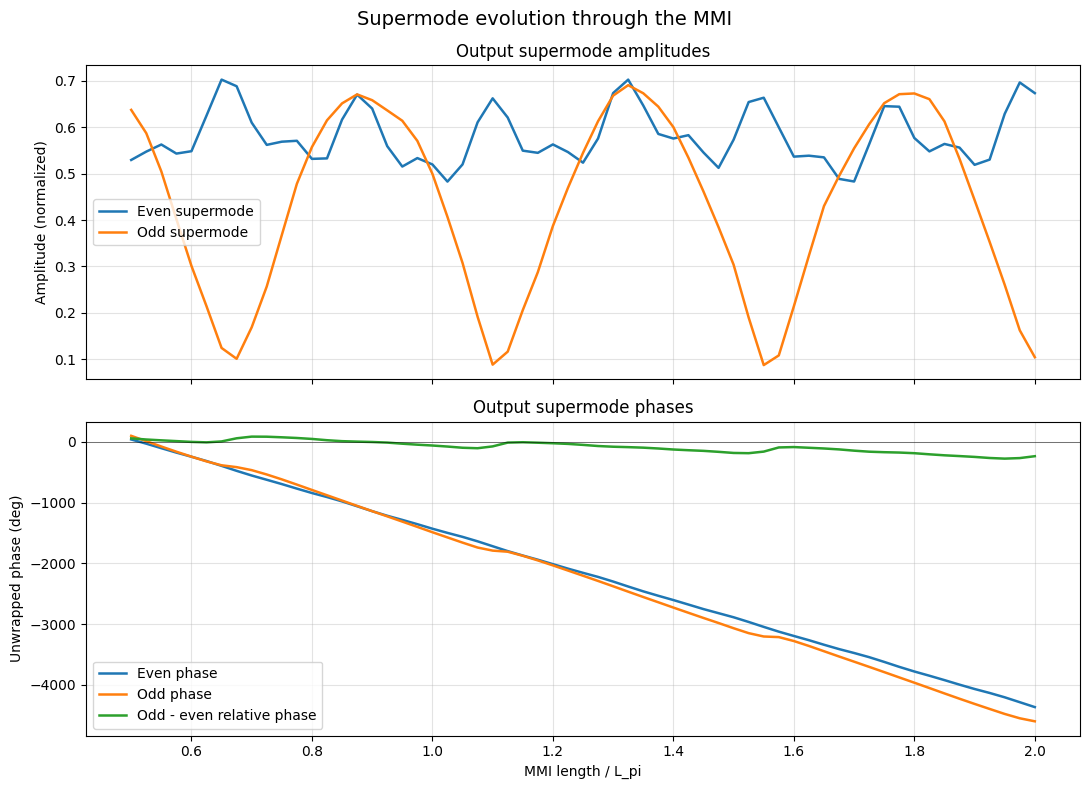

In [24]:
# Sweep the MMI length over multiple beat lengths.
# Replace this scale with a simulated L_pi when an FDE estimate is available.
lpi_um = 100.0
lpi_multiples = np.linspace(0.5, 2.0, 61)

mmi_lpi_summary = lpi_length_sweep(
    sim,
    lpi_um=lpi_um,
    multiples=lpi_multiples,
    filename="mmi2x2_1550nm_lpi_length_sweep.csv",
)
best_lpi_point = select_best_2x2_length(mmi_lpi_summary)
print("Best constrained 2x2 length:")
print(best_lpi_point)

plot_2x2_metrics(mmi_lpi_summary, x_column="length_over_lpi")
plot_supermode_evolution(mmi_lpi_summary)


In [15]:
device_name = 'mmi2x2_ote'

mmi_params = {
    'wavelength': 1.31,
    'w_wg': 2,
    'w_mmi': 7.5,
    's_wg': 2.25,
}

mod_geometry(sim, **mmi_params)
lu.run_eme(sim, f"{device_name}.lms")


Reference point near the original 1.5 um first-section length:
length_um                           1.500000
cell_range                          0.000000
excess_loss_db                      3.328732
insertion_loss_upper_db             7.186497
insertion_loss_lower_db             5.630244
power_imbalance_db                 -1.556252
phase_error_deg                    75.638794
return_loss_db                     28.995692
forward_power                       0.464651
reflected_power                     0.001260
even_amplitude_abs                  0.673666
odd_amplitude_abs                   0.104042
even_power                          0.453826
odd_power                           0.010825
even_phase_deg                    -48.287388
odd_phase_deg                      77.700981
supermode_phase_difference_deg    125.988370
Name: 10, dtype: float64


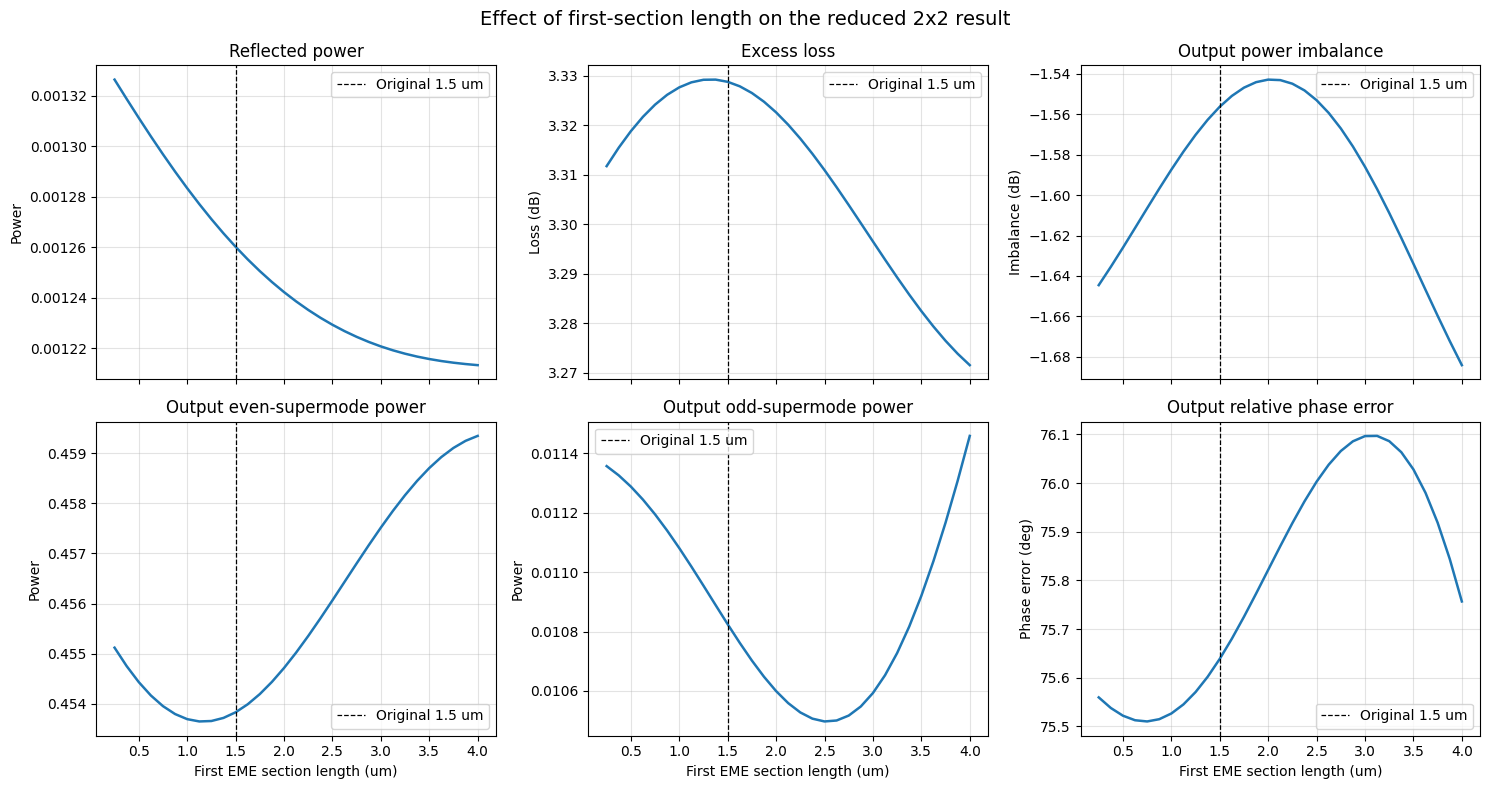

In [28]:
# Propagation-only sweep of the first EME section.
# The modes were already solved above; this changes only group 0 span.
input_section_lengths = np.linspace(0.25, 4.0, 31)
input_section_summary = input_section_length_sweep(
    sim,
    lengths=input_section_lengths,
    filename="mmi2x2_input_section_length_sweep.csv",
)

baseline_index = np.abs(input_section_summary["length_um"] - 1.5).idxmin()
baseline_input_point = input_section_summary.loc[baseline_index]
print("Reference point near the original 1.5 um first-section length:")
print(baseline_input_point)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.ravel()
plot_specs = [
    ("reflected_power", "Reflected power", "Power"),
    ("excess_loss_db", "Excess loss", "Loss (dB)"),
    ("power_imbalance_db", "Output power imbalance", "Imbalance (dB)"),
    ("even_power", "Output even-supermode power", "Power"),
    ("odd_power", "Output odd-supermode power", "Power"),
    ("phase_error_deg", "Output relative phase error", "Phase error (deg)"),
]
for axis, (column, title, ylabel) in zip(axes, plot_specs):
    axis.plot(input_section_summary["length_um"], input_section_summary[column], linewidth=1.8)
    axis.axvline(1.5, color="black", linestyle="--", linewidth=0.9, label="Original 1.5 um")
    axis.set_title(title)
    axis.set_ylabel(ylabel)
    axis.grid(True, alpha=0.35)
    axis.legend()

for axis in axes[-3:]:
    axis.set_xlabel("First EME section length (um)")
fig.suptitle("Effect of first-section length on the reduced 2x2 result", fontsize=14)
fig.tight_layout()
